<a href="https://colab.research.google.com/github/mmeenakshibio2016-byte/Analyzing-the-Trends-of-COVID-19-with-python/blob/main/Recommender_System_using_SVD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
#Recommendation System Prize Dataset using SVD

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/combined_data_1.txt')
df

In [23]:
dataset = pd.read_csv('/content/drive/MyDrive/combined_data_1.txt',header =None,names =['CustId','Rating'],usecols=[0,1])

dataset['Rating'] = dataset['Rating'].astype(float)

In [24]:
dataset.dtypes

,0
CustId,object
Rating,float64


In [25]:
dataset.shape

(24058263, 2)

In [26]:
dataset.head()

,CustId,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0


In [27]:
#To find the distribution of different ratings in the dataset
p = dataset.groupby('Rating')['Rating'].agg(['count'])
p

,count
Rating,
1.0,1118186
2.0,2439073
3.0,6904181
4.0,8085741
5.0,5506583


In [28]:
movie_count = dataset.isnull().sum()[1]
movie_count

/tmp/ipykernel_3067/482069271.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  movie_count = dataset.isnull().sum()[1]


4499

In [29]:
cust_count = dataset['CustId'].nunique() - movie_count
cust_count

470758

In [30]:
rating_count = dataset['CustId'].count() - movie_count
rating_count

24053764

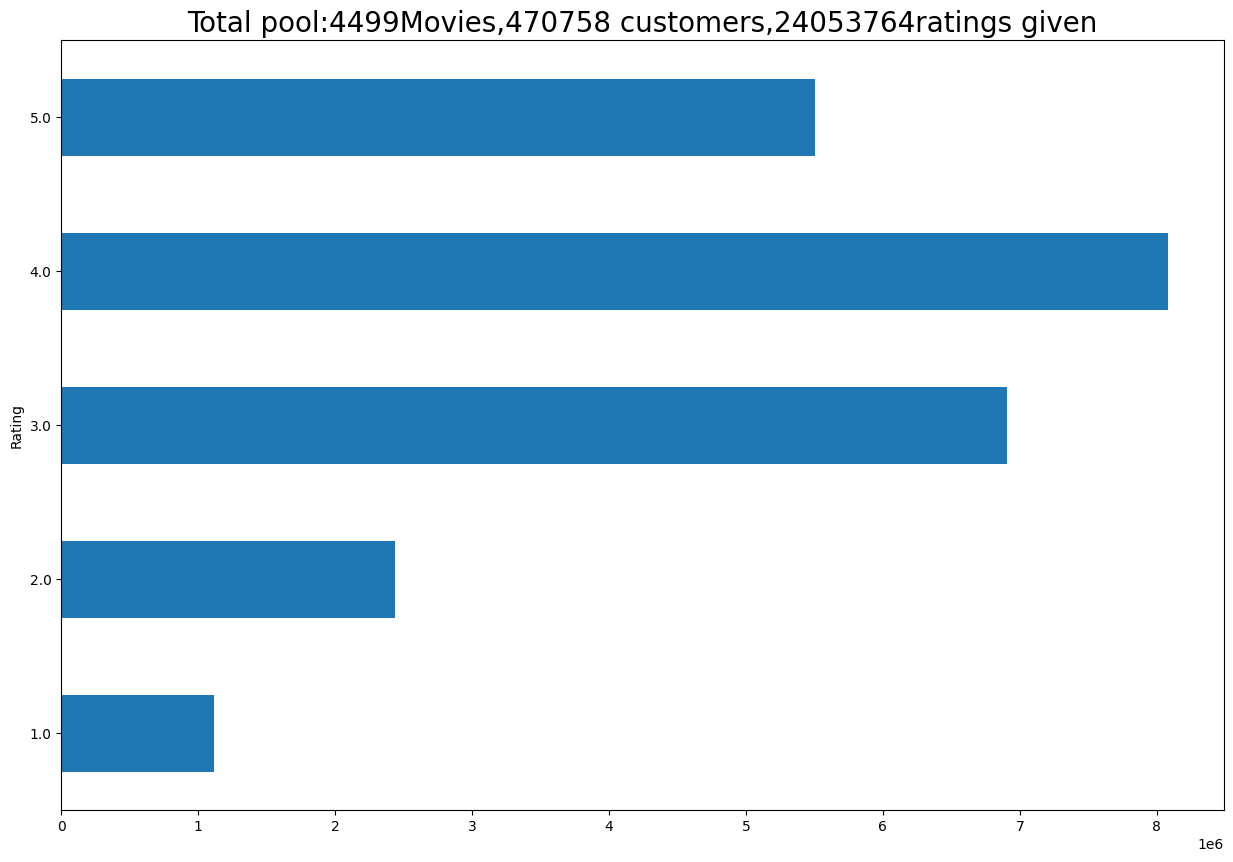

In [31]:
ax = p.plot(kind='barh',legend = False,figsize=(15,10))
plt.title(f'Total pool:{movie_count}Movies,{cust_count} customers,{rating_count}ratings given',fontsize =20)
plt.show()

In [32]:
df_nan = pd.DataFrame(pd.isnull(dataset.Rating))
df_nan.head()

,Rating
0,True
1,False
2,False
3,False
4,False


In [33]:
df_nan = df_nan[df_nan['Rating']== True]
df_nan.shape

(4499, 1)

In [34]:
df_nan

,Rating
0,True
548,True
694,True
2707,True
2850,True
...,...
24046714,True
24047329,True
24056849,True
24057564,True


In [35]:
df_nan = df_nan.reset_index()
df_nan.head()

,index,Rating
0,0,True
1,548,True
2,694,True
3,2707,True
4,2850,True


In [36]:
df_nan['index'][1:]

,index
1,548
2,694
3,2707
4,2850
5,3991
...,...
4494,24046714
4495,24047329
4496,24056849
4497,24057564


In [37]:
df_nan['index'][:-1]

,index
0,0
1,548
2,694
3,2707
4,2850
...,...
4493,24046583
4494,24046714
4495,24047329
4496,24056849


In [38]:
movie_np =[]
movie_id = 1
for i,j in zip(df_nan['index'][1:],df_nan['index'][:-1]):
  temp = np.full((1,i-j-1),movie_id)
  movie_np = np.append(movie_np,temp)
  movie_id +=1
last_record = np.full((1,len(dataset)-df_nan.iloc[-1,0]-1),movie_id)
movie_np = np.append(movie_np,last_record)
print(f'Movie numpy:,{movie_np}')
print(f'Length:,{len(movie_np)}')

Movie numpy:,[1.000e+00 1.000e+00 1.000e+00 ... 4.499e+03 4.499e+03 4.499e+03]
Length:,24053764


In [39]:
df_nan.iloc[-1,0]

24057834

In [40]:
dataset = dataset[pd.notnull(dataset['Rating'])].copy()
dataset['Movie_Id'] = movie_np.astype(int)
dataset['CustId'] = dataset['CustId'].astype(int)
print('-Dataset examples-')
dataset.head()

-Dataset examples-


,CustId,Rating,Movie_Id
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1


In [41]:
dataset.tail()

,CustId,Rating,Movie_Id
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499
24058262,1704416,3.0,4499


In [42]:
dataset.head()

,CustId,Rating,Movie_Id
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1


In [43]:
dataset.tail()

,CustId,Rating,Movie_Id
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499
24058262,1704416,3.0,4499


In [44]:
print('Checking for null values in the dataset:')
display(dataset.isnull().sum())

Checking for null values in the dataset:


,0
CustId,0
Rating,0
Movie_Id,0


In [45]:
dataset.shape

(24053764, 3)

In [46]:
#Data cleaning

In [47]:
f =['count','mean']

In [48]:
f =['count','mean']
dataset_movie_summary = dataset.groupby('Movie_Id')['Rating'].agg(f)
dataset_movie_summary.index = dataset_movie_summary.index.map(int)
movie_benchmark = round(dataset_movie_summary['count'].quantile(0.7))
drop_movie_list = dataset_movie_summary[dataset_movie_summary['count']< movie_benchmark].index
print('Movie minimum times of review:{}'.format(movie_benchmark))

Movie minimum times of review:1799


In [49]:
dataset_cust_summary = dataset.groupby('CustId')['Rating'].agg(f)
dataset_cust_summary.index = dataset_cust_summary.index.map(int)
cust_benchmark = round(dataset_cust_summary['count'].quantile(0.7))
drop_cust_list = dataset_cust_summary[dataset_cust_summary['count']< cust_benchmark].index
print('Customer minimum times of review:{}'.format(cust_benchmark))

Customer minimum times of review:52


In [50]:
print(f'Original Shape:{dataset.shape}')

Original Shape:(24053764, 3)


In [51]:
dataset = dataset[~dataset['Movie_Id'].isin(drop_movie_list)]
dataset = dataset[~dataset['CustId'].isin(drop_cust_list)]
print(f'After Trim Shape:{dataset.shape}')

After Trim Shape:(17337458, 3)


In [52]:
print ('-Data Examples-')
dataset.head()

-Data Examples-


,CustId,Rating,Movie_Id
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3


In [53]:
#Pivot table -proper table

df_p = dataset.pivot_table(index = 'CustId',columns = 'Movie_Id',values = 'Rating')
print(df_p.shape)

(143458, 1350)


In [54]:
df_p.head()

Movie_Id,3,8,16,17,18,26,28,30,32,33,...,4472,4474,4478,4479,4485,4488,4490,4492,4493,4496
CustId,,,,,,,,,,,,,,,,,,,,,
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,5.0,NaN,NaN,NaN,NaN,4.0,5.0,NaN,NaN,...,3.0,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN
79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,...,4.0,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN
97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
134,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
df_title = pd.read_csv('/content/drive/MyDrive/movie_titles _1_.csv',encoding = 'latin1',header = None,names = ['Movie_Id','Year','Name'], engine='python', on_bad_lines='skip')
df_title.head()

,Movie_Id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW


In [56]:
df_title = pd.read_csv('/content/drive/MyDrive/movie_titles _1_.csv',encoding ="Latin-1",header =None,names = ['Movie_Id','Year','Name'], engine='python', on_bad_lines='skip')
df_title.set_index('Movie_Id',inplace = True)
print(df_title.head(10))

            Year                          Name
Movie_Id                                      
1         2003.0               Dinosaur Planet
2         2004.0    Isle of Man TT 2004 Review
3         1997.0                     Character
4         1994.0  Paula Abdul's Get Up & Dance
5         2004.0      The Rise and Fall of ECW
6         1997.0                          Sick
7         1992.0                         8 Man
8         2004.0    What the #$*! Do We Know!?
9         1991.0      Class of Nuke 'Em High 2
10        2001.0                       Fighter


In [57]:
!pip install surprise

In [58]:
!pip install scikit-surprise


In [59]:
import math
import matplotlib.pyplot as plt

# Downgrade numpy to a compatible version and reinstall surprise
!pip uninstall numpy scikit-surprise -y
!pip install numpy==1.26.4
!pip install --upgrade --force-reinstall surprise

# IMPORTANT: After this cell executes, restart the Colab runtime (Runtime -> Restart runtime...)
# Then, re-run the next cell with the imports.


Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scikit-surprise 1.1.4
Uninstalling scikit-surprise-1.1.4:
  Successfully uninstalled scikit-surprise-1.1.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you 

  Using cached surprise-0.1-py2.py3-none-any.whl.metadata (327 bytes)
  Using cached scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
Using cached surprise-0.1-py2.py3-none-any.whl (1.8 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: joblib
    Found existing installation: joblib 1.5.3
    Uninstalling joblib-1.5.3:
      Successfully uninstalled jo

In [60]:
import math
import matplotlib.pyplot as plt

# Uninstall conflicting packages
!pip uninstall numpy scikit-surprise -y

# Install a compatible numpy version (NumPy 1.x)
!pip install numpy==1.26.4

# Install scikit-surprise and surprise.
# Explicitly installing scikit-surprise first ensures it picks up the compatible numpy.
!pip install scikit-surprise==1.1.4
!pip install surprise

# Proceed with the imports
from surprise import Reader, Dataset, SVD
from surprise.model_selection import cross_validate

Found existing installation: numpy 2.4.4
Uninstalling numpy-2.4.4:
  Successfully uninstalled numpy-2.4.4
Found existing installation: scikit-surprise 1.1.4
Uninstalling scikit-surprise-1.1.4:
  Successfully uninstalled scikit-surprise-1.1.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you hav

  Using cached scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl


In [ ]:
reader = Reader()
data = Dataset.load_from_df(dataset[['CustId','Movie_Id','Rating']],reader)
svd = SVD()
cross_validate(svd,data,measures=['RMSE','MAE'],cv=5,verbose=True)

In [ ]:
dataset.head()

In [1]:
print('Basic statistics for the Rating column:')
display(dataset['Rating'].describe())

Basic statistics for the Rating column:


NameError: name 'dataset' is not defined